This is for simulations on synthetic data with two circles, where we add some noise.

The notebook is split into sampling one circle or two circles.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import gudhi.point_cloud.timedelay as td
from tqdm.auto import tqdm
import seaborn as sns
import gudhi.representations as gr

import pandas as pd
from copy import deepcopy
import scipy
import scipy.integrate

import tsi_functions as tsi
import tsi_functions.time_series as tsi_ts

In [ ]:
def SampleOnCircle(N_obs=100, N_out=0, is_plot=False, noise_type="uniform", sigma=1):
    """
    Sample N_obs points (observations) points from the uniform distribution on the unit circle in R^2,
        and N_out points (outliers) from the uniform distribution on the unit square

    Input:
    N_obs: number of sample points on the circle
    N_noise: number of sample points on the square
    is_plot = True or False : draw a plot of the sampled points

    Output :
    data : a (N_obs + N_out)x2 matrix, the sampled points concatenated
    """
    rand_uniform = np.random.rand(N_obs) * 2 - 1
    X_obs = np.cos(2 * np.pi * rand_uniform)
    Y_obs = np.sin(2 * np.pi * rand_uniform)

    if noise_type == "uniform":
        X_out = np.random.rand(N_out) * 2 - 1
        Y_out = np.random.rand(N_out) * 2 - 1

        X = np.concatenate((X_obs, X_out))
        Y = np.concatenate((Y_obs, Y_out))
        data = np.stack((X, Y)).transpose()
    
    elif noise_type == "gaussian":
        X_out = X_obs + np.random.normal(0, sigma, size=X_obs.shape)
        Y_out = Y_obs + np.random.normal(0, sigma, size=Y_obs.shape)

        data = np.stack((X_out, Y_out)).transpose()
    if is_plot:
        fig, ax = plt.subplots()
        plt_obs = ax.scatter(X_obs, Y_obs, c="tab:cyan")
        # plt_out = ax.scatter(X_out, Y_out, c="tab:orange")
        ax.axis("equal")
        ax.set_title(str(N_obs) + "-sampling of the unit circle with " + str(N_out) + " outliers")
        # ax.legend((plt_obs, plt_out), ("data", "outliers"), loc="lower left")
    return data

def simulate_and_compute_circles(N_obs, N_out, noise_type, sigma, n, seed=None, remove_inf_fun = tsi.remove_inf(), complex_type="alpha", summary_functions = tsi.top_summary_functions):
    """
        methods: dict of method name to tuple (use_persistence: Bool, function)
    """
    if seed is not None:
        np.random.seed(seed)
    simulation_results = {
        method: [] for method in summary_functions.function_names
    }
    for i in range(n):
        data_points = SampleOnCircle(N_obs=N_obs, N_out=N_out, is_plot=False, noise_type=noise_type, sigma=sigma)
        if complex_type == "alpha":
            Alpha_complex = gd.AlphaComplex(points=data_points)
            Alpha_simplex_tree_W = Alpha_complex.create_simplex_tree() 
            persistence =  Alpha_simplex_tree_W.persistence()
        elif complex_type == "rips":
            Rips_complex = gd.RipsComplex(points=data_points, max_edge_length=2)
            Rips_simplex_tree_W = Rips_complex.create_simplex_tree(max_dimension=2) 
            persistence =  Rips_simplex_tree_W.persistence()
        func_evals = summary_functions(persistence)
        for method_name in func_evals.keys():
            simulation_results[method_name].append(func_evals[method_name])

    return simulation_results

def plot_simulation_results(simulation_results, params_per_method = None):
    swapped_results = {}
    for param, results in simulation_results.items():
        for method in results.keys():
            if method not in swapped_results:
                swapped_results[method] = {}
            if params_per_method is not None and method.split('-')[0] in params_per_method:
                if param not in params_per_method[method.split('-')[0]]:
                    continue
            swapped_results[method][param] = results[method]
    
    fig, ax = plt.subplots(nrows = int(np.ceil(len(swapped_results)/4)), ncols=min(4, len(swapped_results)), figsize=(5*min(4, len(swapped_results)), 5*(len(swapped_results)//4 + 1)))
    ax = ax.flatten()
    for i, (method, results) in enumerate(swapped_results.items()):
        sns.histplot(data=results, bins=100, ax=ax[i], kde=True, stat="density", element ="step")
        ax[i].set_title(method)
    plt.tight_layout()
    plt.show()

# One circle

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

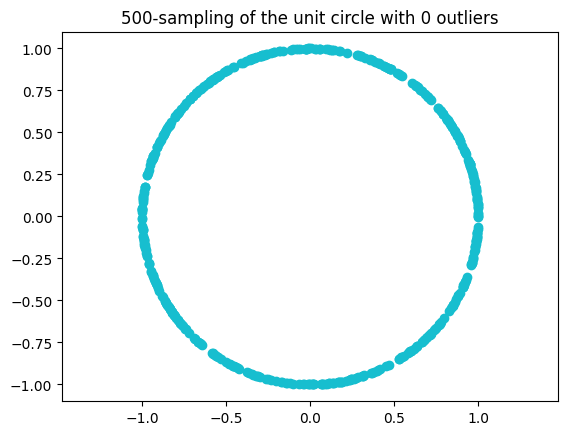

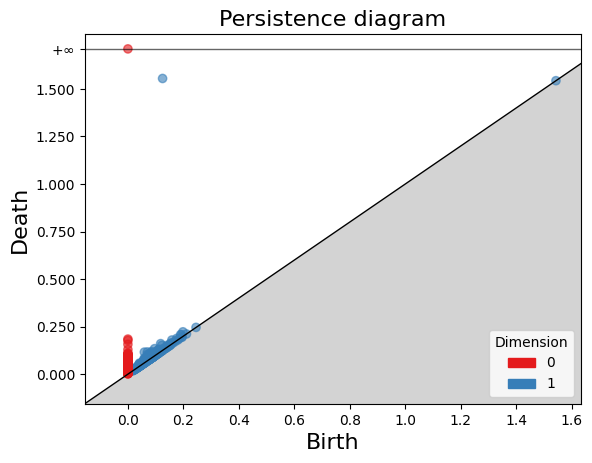

In [7]:
def PointsOnCircle(N, radius=1):
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.column_stack((x, y))


data = SampleOnCircle(N_obs=500, N_out=0, is_plot=True, noise_type="gaussian", sigma=.07)

persistence = tsi.filtration_from_points(data, filtration_type="alpha", max_dim=3, max_edge_length=2)

gd.plot_persistence_diagram(persistence)

# Two circles

In [3]:
from tsi_functions.dtm import estimate_conf_region
def sample_2_circles(N_obs):
    """
    Sample N_obs points from the uniform distribution on the unit circle in R^2,
        and N_out points (outliers) from the uniform distribution on the unit square

    Input:
    N_obs: number of sample points on each circle
    noise_type: "uniform" or "gaussian"
    sigma: standard deviation of the gaussian noise

    Output :
    data : a (2*N_obs)x2 matrix, the sampled points concatenated
    """

    data_1 = SampleOnCircle(N_obs=N_obs//2, N_out=0, is_plot=False, noise_type="gaussian", sigma=0)-np.array([0.75,0])
    data_2 = SampleOnCircle(N_obs=N_obs//2, N_out=0, is_plot=False, noise_type="gaussian", sigma=0)+np.array([0.75,0])
    data = np.concatenate([data_1, data_2])
    return data 



## Examples

TSI: 0.12761376528995017


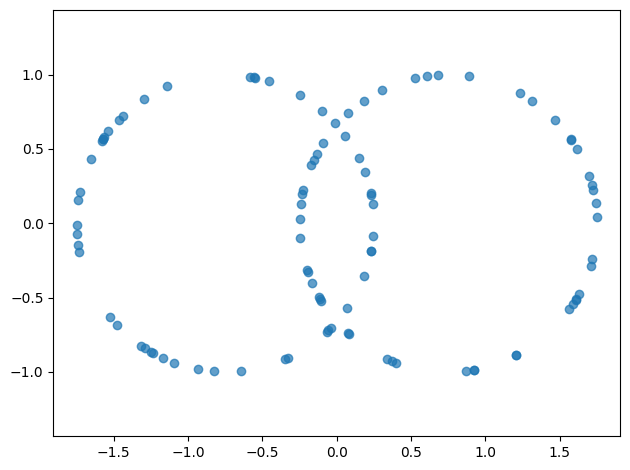

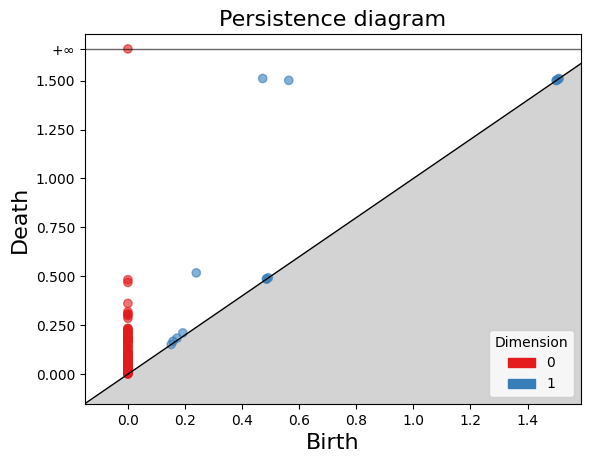

In [89]:
noise = 0.
max_edge_length = 1.75
filtration_type = "alpha"
N_obs = 100
dtm = False

np.random.seed(122)

data = sample_2_circles(N_obs=N_obs)
data += np.random.normal(0, noise, size=data.shape)
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.axis("equal")
plt.tight_layout()
# plt.savefig("figures/sampled_circles.png", dpi=300, bbox_inches='tight')

persistence = tsi.filtration_from_points(data, filtration_type=filtration_type, max_dim=2, max_edge_length=max_edge_length, dtm=dtm)

print("TSI:", tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)["TSI-1"])

# bars_dict = {}
# for dim, bar in persistence:
#     bars_dict.setdefault(dim, []).append(bar)
# print(bars_dict[1])
# bars_dict = {dim: tsi.top_summary_functions.remove_inf_fun(bars_dict[dim], theoretical_max = max_edge_length) for dim in bars_dict.keys()}
# print(bars_dict[1])

n_bootstrap = 1000
# conf = estimate_conf_region(data, alpha=0.9, m=0.03, n=n_bootstrap, loading_bar = True)
# print(conf)
# hatc = ps.hausd_interval(data=data,level = 0.9, m = -1, B=10000)
# print(hatc)
plt.tight_layout()
# plt.savefig("sampled_circles.png")

gd.plot_persistence_diagram(persistence)#, band=2*hatc)
plt.savefig("figures/sampled_circles_pd_alpha.png", dpi=300, bbox_inches='tight')

## No Noise Analysis

In [75]:
def simulate_and_compute_2_circles(N_obs, n, seed=None, remove_inf_fun = tsi.remove_inf(), complex_type="alpha", max_edge_length = 2, summary_functions = tsi.top_summary_functions):
    """
        methods: dict of method name to tuple (use_persistence: Bool, function)
    """
    if seed is not None:
        np.random.seed(seed)
    simulation_results = {
        method: [] for method in summary_functions.function_names
    }
    for i in tqdm(range(n), leave=False):
        data_points = sample_2_circles(N_obs=N_obs)
        persistence = tsi.filtration_from_points(data_points, filtration_type=complex_type, max_dim=2, max_edge_length=max_edge_length)
        func_evals = summary_functions(persistence)
        for method_name in func_evals.keys():
            simulation_results[method_name].append(func_evals[method_name])

    return simulation_results

In [ ]:
sim_reses = {}
n = 100
N_obs_list = np.linspace(10, 200, 41, dtype=int)

np.random.seed(123)

for N_obs in tqdm(N_obs_list):
    sim_res = simulate_and_compute_2_circles(N_obs=N_obs, n=n, complex_type="rips", max_edge_length=1.75)
    sim_reses[N_obs] = sim_res

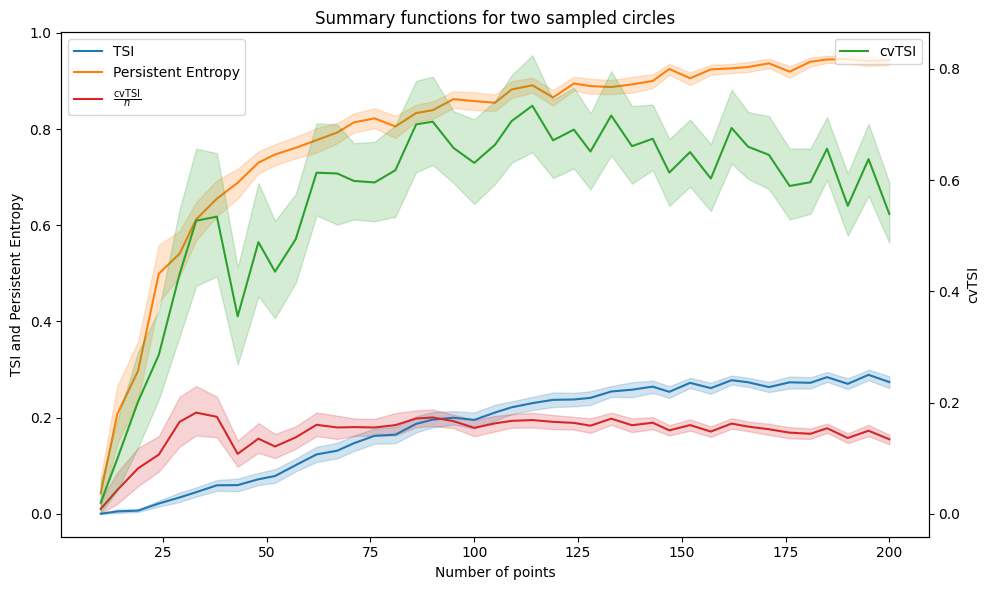

In [101]:
fig, ax = plt.subplots(figsize=(10, 6))

ax_right = ax.twinx()


sns.lineplot(y=np.concatenate([np.nan_to_num(sim_reses[N_obs]["TSI-1"]) for N_obs in N_obs_list]), x=np.repeat(N_obs_list, n), label="TSI", errorbar=("ci", 95), color="tab:blue", ax=ax)
sns.lineplot(y=np.concatenate([np.nan_to_num(sim_reses[N_obs]["persistent_entropy-1"]) for N_obs in N_obs_list]), x=np.repeat(N_obs_list, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax)
sns.lineplot(y=np.concatenate([np.nan_to_num(sim_reses[N_obs]["cvTSI-1"]) for N_obs in N_obs_list]), x=np.repeat(N_obs_list, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(sim_reses[N_obs]["normalized_cvTSI-1"]) for N_obs in N_obs_list]), x=np.repeat(N_obs_list, n), label=r"$\frac{\text{cvTSI}}{n}$", errorbar=("ci", 95), color="tab:red", ax=ax)
# sns.lineplot(y=np.concatenate([np.nan_to_num(sim_reses[N_obs]["TSigI-1"]) for N_obs in N_obs_list]), x=np.repeat(N_obs_list, n), label="TSigI", errorbar=("ci", 95), color="tab:red")

ax.legend(loc="upper left")
ax_right.legend(loc="upper right")

ax.set_xlabel("Number of points")
ax.set_ylabel("TSI and Persistent Entropy")
ax_right.set_ylabel("cvTSI")
plt.title("Summary functions for two sampled circles")
plt.tight_layout()
plt.savefig("figures/sampled_circles_summary_functions_rips_ncvtsi.png", dpi=300, bbox_inches='tight')
plt.legend()

## Gaussian Noise Analysis

In the code below, we sample the points multiple times with different amount of noise and compute all the summary functions on it.

In [15]:
n_point_samples = 100
n_noise_samples = 1
N_obs = 200
max_edge_length = 1.75
max_dim = 2
dtm = False
filtration_type = "rips"

np.random.seed(123)

noise_levels = np.linspace(0, 0.5, 51)

two_circle_simulation_results_different_gaussian_noise = {}
point_bar = tqdm(range(n_point_samples))
for point_sample_i in point_bar:
    data = sample_2_circles(N_obs=N_obs)
    for noise_level in noise_levels:
        point_bar.set_description(f"Point sample {point_sample_i+1}/{n_point_samples}, noise level {noise_level:.4f}")

        if noise_level > 0:
            for noise_i in range(n_noise_samples):
                noisy_data = data + np.random.normal(0, noise_level, size=data.shape)
                persistence =  tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length, dtm=dtm, max_dim=max_dim)

                fun_evals = tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)
                for method_name, fun_eval in fun_evals.items():
                    two_circle_simulation_results_different_gaussian_noise.setdefault(method_name, {}).setdefault(noise_level, []).append(fun_eval)
        else:
            persistence =  tsi.filtration_from_points(data, filtration_type=filtration_type, max_edge_length=max_edge_length, dtm=dtm, max_dim=max_dim)

            fun_evals = tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)
            for method_name, fun_eval in fun_evals.items():
                two_circle_simulation_results_different_gaussian_noise.setdefault(method_name, {}).setdefault(noise_level, []).append(fun_eval)




  0%|          | 0/100 [00:00<?, ?it/s]

In [4]:
import pickle

# with open("results/two_circles/rips_gaussian_noise_075_seed123.pkl", "wb") as f:
#     pickle.dump(two_circle_simulation_results_different_gaussian_noise, f)

with open("results/two_circles/rips_gaussian_noise_075_seed123.pkl", "rb") as f:
    two_circle_simulation_results_different_gaussian_noise = pickle.load(f)

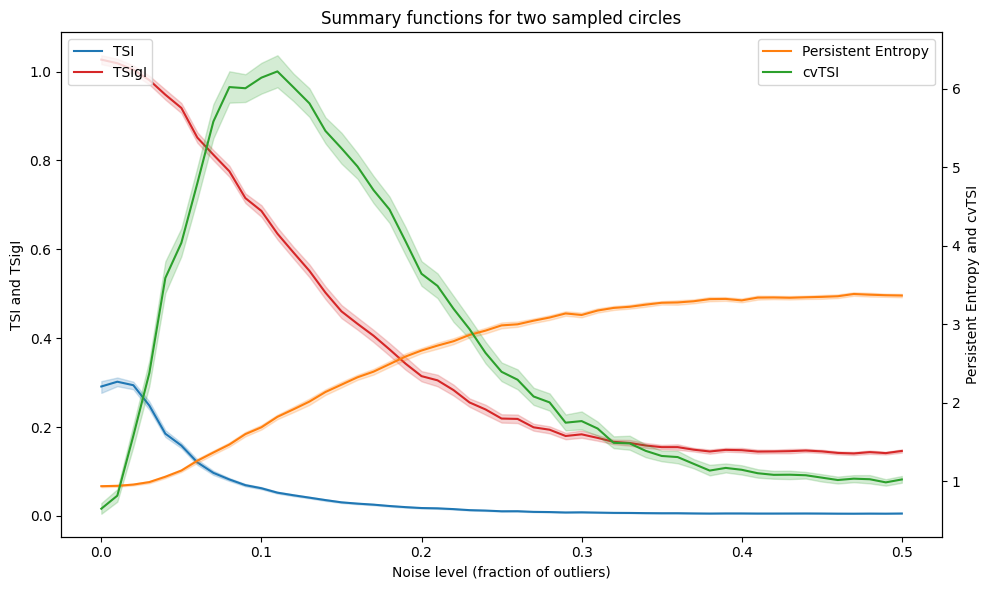

In [6]:
noise_levels = np.linspace(0, 0.5, 51)

n=100

fig, ax_left = plt.subplots(figsize=(10, 6))

ax_right = ax_left.twinx()

sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_gaussian_noise["TSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="TSI", errorbar=("ci", 95), color="tab:blue", ax=ax_left)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_gaussian_noise["persistent_entropy-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_gaussian_noise["cvTSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_gaussian_noise["TSigI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="TSigI", errorbar=("ci", 95), color="tab:red", ax=ax_left)
# sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_gaussian_noise["normalized_cvTSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label=r"$\frac{\text{cvTSI}}{n}$", errorbar=("ci", 95), color="tab:purple", ax=ax_left)

ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")
ax_left.set_ylabel("TSI and TSigI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")


# plt.xlabel("Num")
ax_left.set_xlabel("Noise level (fraction of outliers)")
# plt.ylabel("Summary function value")
plt.title("Summary functions for two sampled circles")
plt.tight_layout()
plt.savefig("figures/two_circles_gaussian_noise.png", dpi=300)
# plt.legend()

### Uniform noise

(np.float64(-1.9242441682504965),
 np.float64(1.9176702873236062),
 np.float64(-1.0999488949620795),
 np.float64(1.0999949946736147))

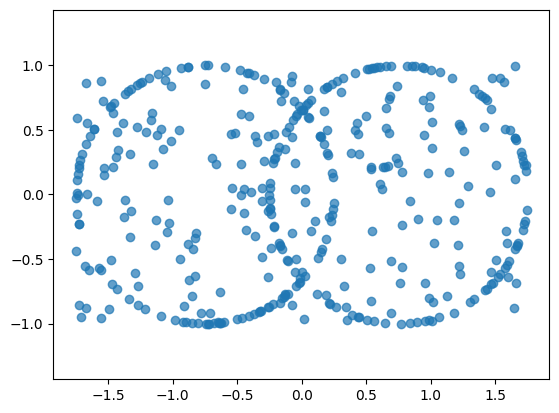

In [5]:
N_obs = 200
frac_noise = 1
N_out = int(frac_noise*N_obs)

data = sample_2_circles(N_obs=200)
X_out = np.random.rand(N_out) * 3.5 - 1.75
Y_out = np.random.rand(N_out) * 2 - 1

data = np.concatenate([data, np.vstack([X_out, Y_out]).T])
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.axis("equal")

In [25]:
n_point_samples = 100
n_noise_samples = 1
N_obs = 100
max_edge_length = 1.75
filtration_type = "rips"
max_dim = 2
dtm = False

np.random.seed(123)

noise_levels = np.linspace(0, 1, 51)

two_circle_simulation_results_different_uniform_noise = {}
point_bar = tqdm(range(n_point_samples))
for point_sample_i in point_bar:
    data = sample_2_circles(N_obs=N_obs)
    for frac_noise in noise_levels:
        point_bar.set_description(f"Point sample {point_sample_i+1}/{n_point_samples}, noise level {frac_noise:.4f}")

        if frac_noise > 0:
            for noise_i in range(n_noise_samples):
                N_out = int(frac_noise*N_obs)
                X_out = np.random.rand(N_out) * 3.5 - 1.75
                Y_out = np.random.rand(N_out) * 2 - 1

                noisy_data = np.concatenate([data, np.vstack([X_out, Y_out]).T])

                persistence =  tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length, max_dim=max_dim, dtm=dtm)

                fun_evals = tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)
                for method_name, fun_eval in fun_evals.items():
                    two_circle_simulation_results_different_uniform_noise.setdefault(method_name, {}).setdefault(frac_noise, []).append(fun_eval)
        else:
            persistence =  tsi.filtration_from_points(data, filtration_type=filtration_type, max_edge_length=max_edge_length, max_dim=max_dim, dtm=dtm)

            fun_evals = tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)
            for method_name, fun_eval in fun_evals.items():
                two_circle_simulation_results_different_uniform_noise.setdefault(method_name, {}).setdefault(frac_noise, []).append(fun_eval)

  0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
import pickle

# with open("results/two_circles/rips_uniform_noise_075_seed123.pkl", "wb") as f:
#     pickle.dump(two_circle_simulation_results_different_uniform_noise, f)

with open("results/two_circles/rips_uniform_noise_075_seed123.pkl", "rb") as f:
    two_circle_simulation_results_different_uniform_noise = pickle.load(f)

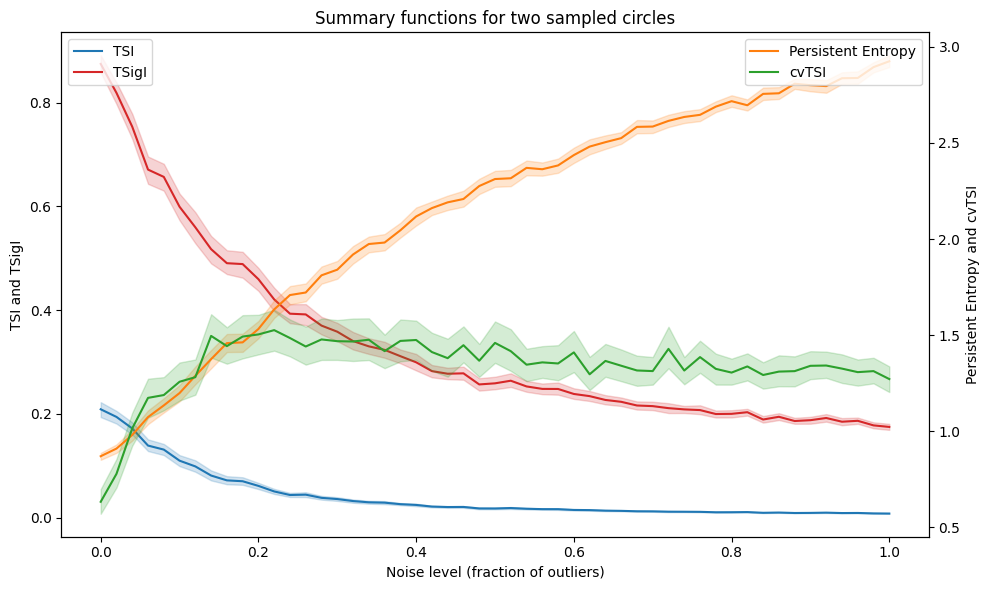

In [10]:
n=100

noise_levels = np.linspace(0, 1, 51)

fig, ax_left = plt.subplots(figsize=(10, 6))

ax_right = ax_left.twinx()

sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["TSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="TSI", errorbar=("ci", 95), color="tab:blue", ax=ax_left)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["persistent_entropy-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["cvTSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["TSigI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="TSigI", errorbar=("ci", 95), color="tab:red", ax=ax_left)
# sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["normalized_cvTSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label=r"$\frac{\text{cvTSI}}{n}$", errorbar=("ci", 95), color="tab:purple", ax=ax_left)

ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")
ax_left.set_ylabel("TSI and TSigI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")


# plt.xlabel("Num")
ax_left.set_xlabel("Noise level (fraction of outliers)")
# plt.ylabel("Summary function value")
plt.title("Summary functions for two sampled circles")
plt.tight_layout()
plt.savefig("figures/two_circles_uniform_noise.png", dpi=300)
# plt.legend()

Text(0.5, 1.0, 'Summary functions for two sampled circles')

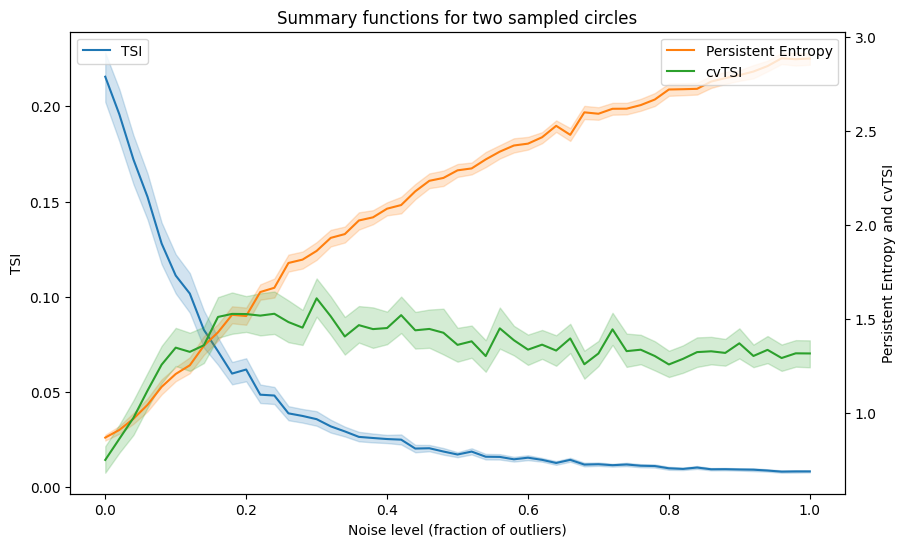

In [12]:
n=100

fig, ax_left = plt.subplots(figsize=(10, 6))

ax_right = ax_left.twinx()

sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["TSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="TSI", errorbar=("ci", 95), color="tab:blue", ax=ax_left)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["persistent_entropy-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="Persistent Entropy", errorbar=("ci", 95), color="tab:orange", ax=ax_right)
sns.lineplot(y=np.concatenate([np.nan_to_num(two_circle_simulation_results_different_uniform_noise["cvTSI-1"][noise_level]) for noise_level in noise_levels]), x=np.repeat(noise_levels, n), label="cvTSI", errorbar=("ci", 95), color="tab:green", ax=ax_right)

ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")
ax_left.set_ylabel("TSI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")


# plt.xlabel("Num")
ax_left.set_xlabel("Noise level (fraction of outliers)")
# plt.ylabel("Summary function value")
plt.title("Summary functions for two sampled circles")
# plt.legend()

### PC

In [ ]:
from tsi_functions.persistent_curves import PersistentCurve

filtration_type = "alpha"
n_point_samples = 100
n_noise_samples = 10
N_obs = 200
max_edge_length = .5

noise_levels = [0, 0.05, 0.1]

pc_gaussian_rips = {"TSI": {}, "persistent_entropy": {}}
point_bar = tqdm(range(n_point_samples))
for point_sample_i in point_bar:
    data = sample_2_circles(N_obs=N_obs)
    for noise_level in noise_levels:
        point_bar.set_description(f"Point sample {point_sample_i+1}/{n_point_samples}, noise level {noise_level:.4f}")

        if noise_level > 0:
            for noise_i in range(n_noise_samples):
                noisy_data = data + np.random.normal(0, noise_level, size=data.shape)
                persistence = tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length)

                pc_gaussian_rips["TSI"].setdefault(noise_level, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: (d-b-bars_out)**2, T=np.sum, bars_fun = lambda bars: np.mean(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
                pc_gaussian_rips["persistent_entropy"].setdefault(noise_level, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: -(d-b)/bars_out*np.log((d-b)/np.sum(bars_out)), T=np.sum, bars_fun = lambda bars: np.sum(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
        else:
            persistence = tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length)

            pc_gaussian_rips["TSI"].setdefault(noise_level, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: (d-b-bars_out)**2, T=np.sum, bars_fun = lambda bars: np.mean(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
            pc_gaussian_rips["persistent_entropy"].setdefault(noise_level, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: -(d-b)/bars_out*np.log((d-b)/np.sum(bars_out)), T=np.sum, bars_fun = lambda bars: np.sum(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))


  0%|          | 0/100 [00:00<?, ?it/s]

TSI0:   0%|          | 0/100 [00:00<?, ?it/s]

TSI0.05:   0%|          | 0/1000 [00:00<?, ?it/s]

TSI0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

persistent_entropy0:   0%|          | 0/100 [00:00<?, ?it/s]

persistent_entropy0.05:   0%|          | 0/1000 [00:00<?, ?it/s]

persistent_entropy0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

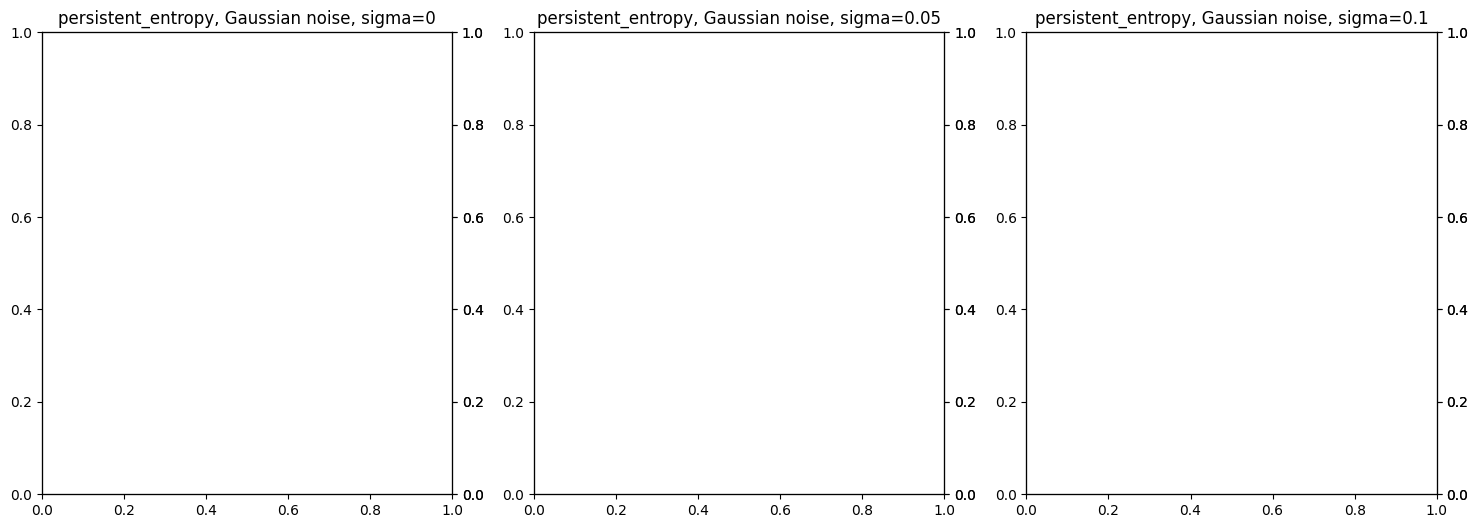

In [ ]:
n_evaluations = 200

fig, ax = plt.subplots(ncols = 3, figsize=(18, 6))

evaluations = {}
for computation_method in ["TSI", "persistent_entropy"]: 
    evaluations[computation_method] = {}
    for sigma_i, sigma in enumerate(noise_levels):
        max_death = 0

        for pc in pc_gaussian_rips[computation_method][sigma]:
            max_death = max(max_death, pc.max_death)

        evaluations[computation_method].setdefault(sigma, {})
        for pc in tqdm(pc_gaussian_rips[computation_method][sigma], desc=computation_method+str(sigma), leave=False):
            curve_values = pc.compute_curve(t_values=np.linspace(0, max_death, n_evaluations))
            for dim in curve_values.keys():
                evaluations[computation_method][sigma].setdefault(dim, [])
                evaluations[computation_method][sigma][dim].append(curve_values[dim])

        evaluations[computation_method][sigma] = {dim: np.concatenate(evaluations[computation_method][sigma][dim]) for dim in evaluations[computation_method][sigma].keys()}

        ax[sigma_i].set_title(computation_method+", Gaussian noise, sigma="+str(sigma))
        ax_left = ax[sigma_i]
        ax_right = ax_left.twinx()


    # sns.lineplot(x=np.tile(np.linspace(0, max_death, n_evaluations), len(pc_gaussian_rips[computation_method][sigma])), y=evaluations[computation_method][sigma][0], label="Dimension "+str(0), ax=ax_left, color="tab:blue")
    # sns.lineplot(x=np.tile(np.linspace(0, max_death, n_evaluations), len(pc_gaussian_rips[computation_method][sigma])), y=evaluations[computation_method][sigma][1], label="Dimension "+str(1), ax=ax_right, color="tab:orange")

    # plt.plot(np.linspace(0, max_death, 1000), evaluations[computation_method][sigma][dim]/len(pc_gaussian_rips[computation_method][sigma]), label="Dimension "+str(dim))

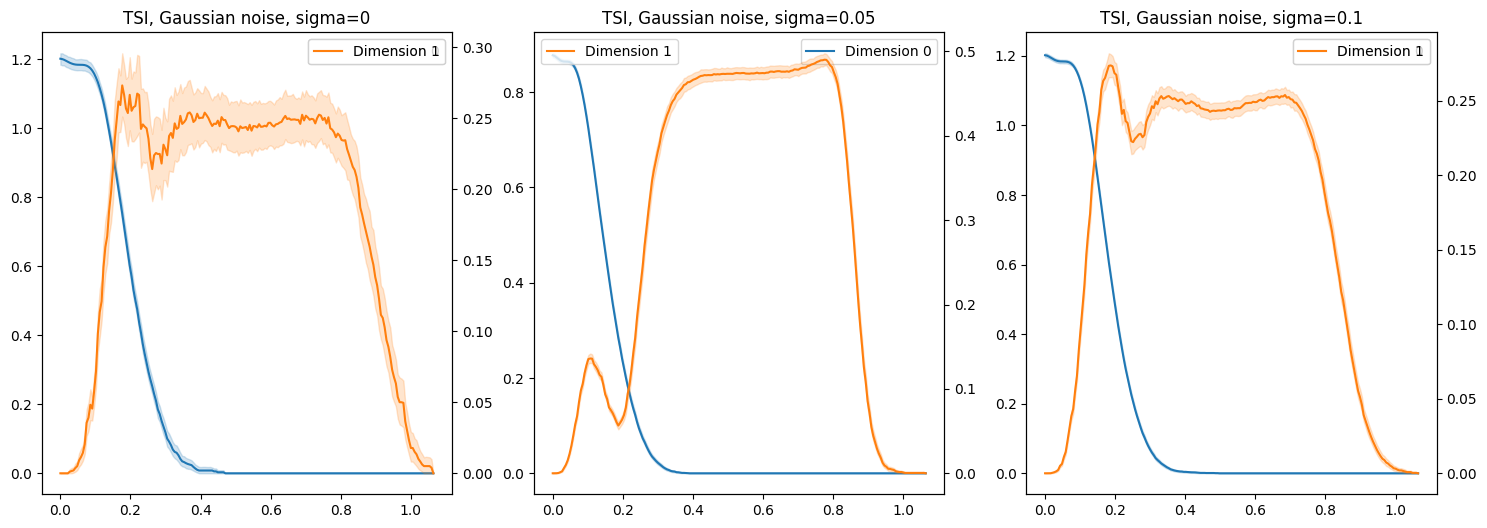

In [ ]:
computation_method = "TSI"

fig, ax = plt.subplots(ncols = 3, figsize=(18, 6))

for sigma_i, sigma in enumerate(noise_levels):
    ax[sigma_i].set_title(computation_method+", Gaussian noise, sigma="+str(sigma))
    ax_left = ax[sigma_i]
    ax_right = ax_left.twinx()
    sns.lineplot(x=np.tile(np.linspace(0, max_death, n_evaluations), len(pc_gaussian_rips[computation_method][sigma])), y=evaluations[computation_method][sigma][0], label="Dimension "+str(0), ax=ax_left, color="tab:blue")
    sns.lineplot(x=np.tile(np.linspace(0, max_death, n_evaluations), len(pc_gaussian_rips[computation_method][sigma])), y=evaluations[computation_method][sigma][1], label="Dimension "+str(1), ax=ax_right, color="tab:orange")


In [ ]:
# import pickle

# with open("results/two_circles/pc_rips_gaussian_200.pkl", "wb") as f:
#     pickle.dump(evaluations, f)

### PC Uniform

In [ ]:
n_point_samples = 100
n_noise_samples = 10
N_obs = 200
max_edge_length = 0.5
filtration_type = "rips"

noise_levels = [0, 0.1, 0.2]

pc_uniform = {"TSI": {}, "persistent_entropy": {}}
point_bar = tqdm(range(n_point_samples))
for point_sample_i in point_bar:
    data = sample_2_circles(N_obs=N_obs)
    for frac_noise in noise_levels:
        point_bar.set_description(f"Point sample {point_sample_i+1}/{n_point_samples}, noise level {frac_noise:.4f}")

        if frac_noise > 0:
            for noise_i in range(n_noise_samples):
                N_out = int(frac_noise*N_obs)
                X_out = np.random.rand(N_out) * 3 - 1.5
                Y_out = np.random.rand(N_out) * 2 - 1

                noisy_data = np.concatenate([data, np.vstack([X_out, Y_out]).T])


                persistence = tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length)

                
                pc_uniform["TSI"].setdefault(frac_noise, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: (d-b-bars_out)**2, T=np.sum, bars_fun = lambda bars: np.mean(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
                pc_uniform["persistent_entropy"].setdefault(frac_noise, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: -(d-b)/bars_out*np.log((d-b)/np.sum(bars_out)), T=np.sum, bars_fun = lambda bars: np.sum(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
        else:
            persistence = tsi.filtration_from_points(noisy_data, filtration_type=filtration_type, max_edge_length=max_edge_length)

            
            pc_uniform["TSI"].setdefault(frac_noise, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: (d-b-bars_out)**2, T=np.sum, bars_fun = lambda bars: np.mean(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))
            pc_uniform["persistent_entropy"].setdefault(frac_noise, []).append(PersistentCurve(persistence, psi=lambda bars_out, b, d, t: -(d-b)/bars_out*np.log((d-b)/np.sum(bars_out)), T=np.sum, bars_fun = lambda bars: np.sum(bars), remove_inf_fun=tsi.remove_inf(lambda_=1)))

  0%|          | 0/100 [00:00<?, ?it/s]

# Non-random

In [33]:
2*np.cos(np.pi/6), 0.5*np.cos(np.pi/6)

(np.float64(1.7320508075688774), np.float64(0.43301270189221935))

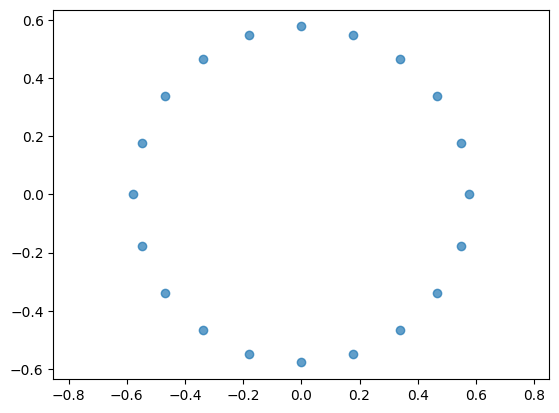

exact birth 0.3901806440322565 0.35355339059327373
approximate birth 0.39269908169872414 0.39269908169872414
dist 0,1: 0.18063496100302476 dist 0,2: 0.35682208977308993 dist 0,3: 0.5242230744683201 dist 0,n//4-1: 0.9341723589627157
[(1, (0.1806349610030249, 1.028845713179734))]
TSI: 0
Entropy: -0.0


/home/siroj/miniconda3/envs/brownian_motion/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/siroj/miniconda3/envs/brownian_motion/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

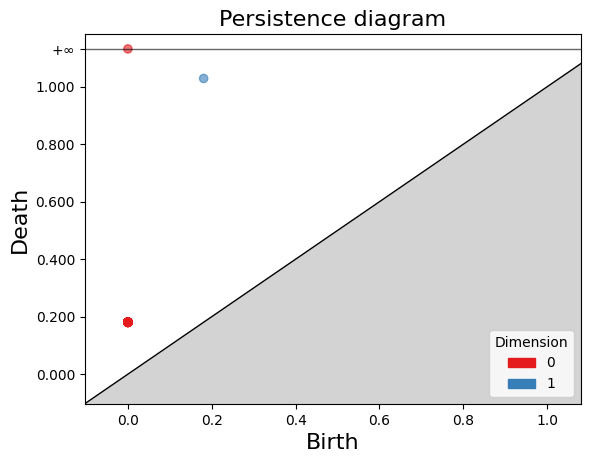

In [72]:
def PointsOnCircle(N, radius=1):
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.column_stack((x, y))

def PointsOnTwoCircles(N, radii = [1, 1], centres = [(-1.5, 0), (1.5, 0)]):
    data_1 = PointsOnCircle(int((N* radii[0])/sum(radii)), radius=radii[0]) + np.array(centres[0])
    data_2 = PointsOnCircle(int((N* radii[1])/sum(radii)), radius=radii[1]) + np.array(centres[1])
    data = np.concatenate([data_1, data_2])
    return data

def PointsOnThreeCircles(N, radii = [1, 1, 1], centres = [(-1, 0), (1, 0), (0, 1)]):
    data_1 = PointsOnCircle(int((N* radii[0])/sum(radii)), radius=radii[0]) + np.array(centres[0])
    data_2 = PointsOnCircle(int((N* radii[1])/sum(radii)), radius=radii[1]) + np.array(centres[1])
    data_3 = PointsOnCircle(int((N* radii[2])/sum(radii)), radius=radii[2]) + np.array(centres[2])
    data = np.concatenate([data_1, data_2, data_3])
    return data

max_edge_length = 20
n = 20
# data = PointsOnTwoCircles(n, radii=[1, 0.25], centres=[(-7.5, 0), (7.5, 0)])
# data = PointsOnCircle(n, radius = 4*1/(n-1)*(np.sin((n-2)/(2*n)*np.pi))/np.sin(2*np.pi/n))
data = PointsOnCircle(n, radius = 1/(2*np.cos(np.pi/6)))
# data = PointsOnCircle(n, radius = 4*1/(n-1)*(np.sin((n-2)/(2*n)*np.pi))/np.sin(2*np.pi/n))
# data[0] = np.array([3.8,0])



# data = np.array([[0,0],[0,1e-15],[0,2e-15],[0,3e-15],[4,0]])
# data += np.random.normal(0, 0.05, size=data.shape)
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.axis("equal")
# plt.savefig("/mnt/c/PhD/TSI/figures/single_bar_points.png", dpi=300, bbox_inches='tight')
plt.show()
persistence = tsi.filtration_from_points(data, filtration_type="rips", max_dim=2, max_edge_length=max_edge_length, dtm=False)
print("exact birth", 2*np.sin(np.pi/(4*(n)//5)), 2*0.25*np.sin(np.pi/((n)//5)))
print("approximate birth", 2*(np.pi/(4*(n)//5)), 2*0.25*(np.pi/((n)//5)))
print("dist 0,1:", np.linalg.norm(data[0]-data[1]), "dist 0,2:", np.linalg.norm(data[0]-data[2]), "dist 0,3:", np.linalg.norm(data[0]-data[3]), "dist 0,n//4-1:", np.linalg.norm(data[0]-data[n//4+1]))
print( [persistence[i] for i in range(len(persistence)) if persistence[i][0] == 1])
print("TSI:", tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)["TSI-1"])
print("Entropy:", tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)["persistent_entropy-1"])
# print([bar for dim, bar in persistence if dim == 1])
# plt.hist([bar[1]-bar[0] for dim, bar in persistence if dim == 1], bins=100)
gd.plot_persistence_diagram(persistence)

(np.float64(-1.925),
 np.float64(1.925),
 np.float64(-1.0978294012710987),
 np.float64(1.0978294012710987))

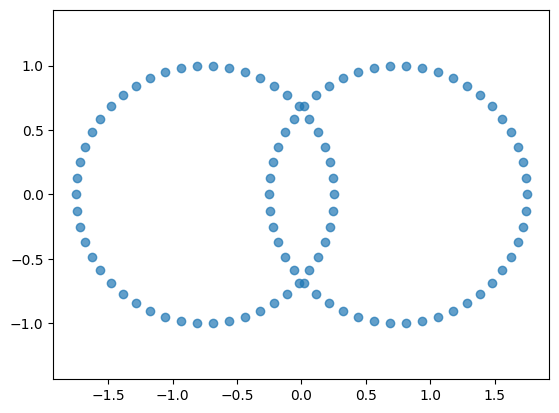

In [15]:
radii = [1, 1]
centres = [(-0.75, 0), (0.75, 0)]

data = PointsOnTwoCircles(100, radii=radii, centres=centres)
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.axis("equal")

  0%|          | 0/191 [00:00<?, ?it/s]

/tmp/ipykernel_46301/1573501321.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


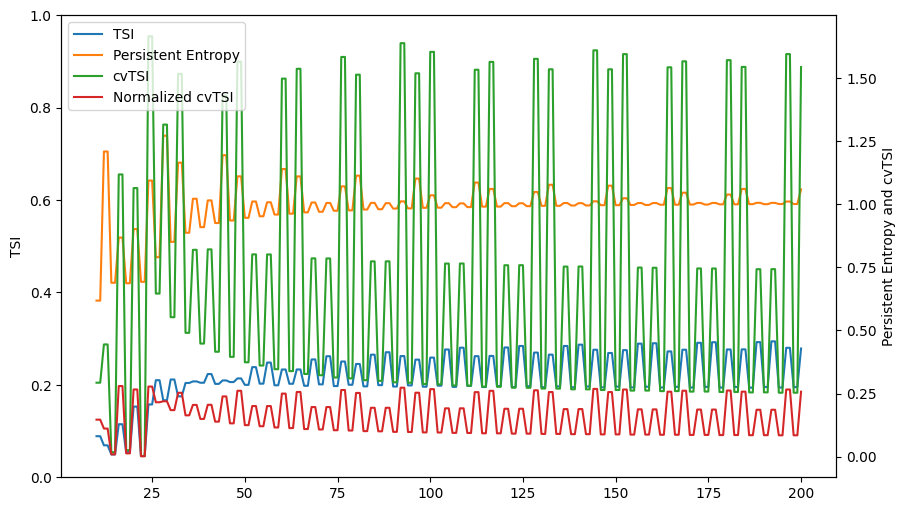

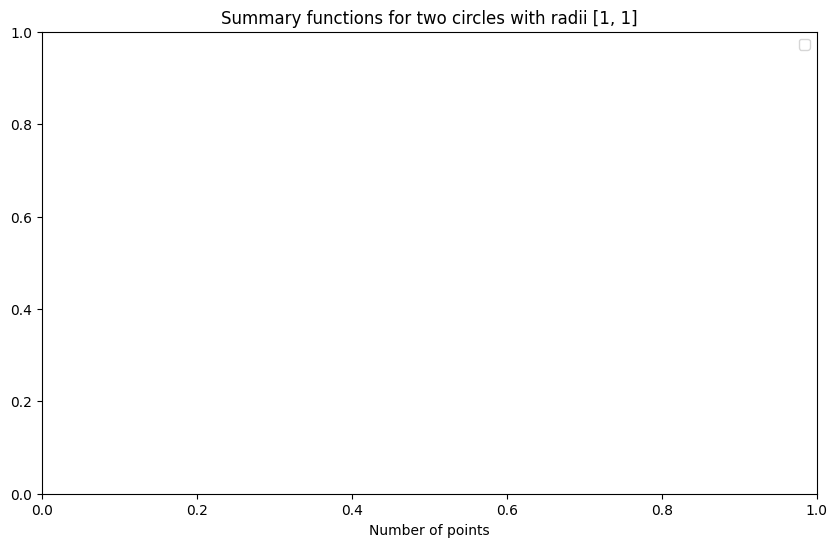

In [16]:
radii = [1, 1]
centres = [(-0.75, 0), (0.75, 0)]
n_list = np.linspace(10, 200, 191, dtype=int)
max_edge_length = max(radii)*2


results = {"TSI": [], "persistent_entropy": [], "cvTSI": [], "normalized_cvTSI": [], "max_length": [], "mean_length": [], "n_bars": []}
for n in tqdm(n_list):
    data = PointsOnTwoCircles(n, radii=radii, centres=centres)
    # data += np.random.normal(0, 0.05, size=data.shape)
    persistence = tsi.filtration_from_points(data, filtration_type="rips", max_dim=2, max_edge_length=max_edge_length, dtm=False)
    fun_evals = tsi.top_summary_functions(persistence, theoretical_max_r=max_edge_length)
    results["TSI"].append(fun_evals["TSI-1"])
    results["persistent_entropy"].append(fun_evals["persistent_entropy-1"])
    results["cvTSI"].append(fun_evals["cvTSI-1"])
    results["normalized_cvTSI"].append(fun_evals["normalized_cvTSI-1"])
    results["max_length"].append(fun_evals["max_length-1"])
    results["mean_length"].append(fun_evals["mean_length-1"])
    results["n_bars"].append(len([bar for dim, bar in persistence if dim == 1]))

fig, ax_left = plt.subplots(figsize=(10, 6))
ax_right = ax_left.twinx()

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_list, y=results["TSI"], label="TSI", color="tab:blue", ax=ax_right)
sns.lineplot(x=n_list, y=results["persistent_entropy"], label="Persistent Entropy", color="tab:orange", ax=ax_right)
sns.lineplot(x=n_list, y=np.array(results["cvTSI"]), label="cvTSI", color="tab:green", ax=ax_right)
sns.lineplot(x=n_list, y=np.array(results["normalized_cvTSI"]), label="Normalized cvTSI", color="tab:red", ax=ax_right)

ax_left.set_ylabel("TSI")
ax_right.set_ylabel("Persistent Entropy and cvTSI")
# sns.lineplot(x=n_list, y=results["max_length"], label="Max Length", color="tab:red")
# sns.lineplot(x=n_list, y=results["mean_length"], label="Mean Length", color="tab:purple")
# sns.lineplot(x=n_list, y=results["n_bars"], label="Number of bars", color="tab:brown")
plt.xlabel("Number of points")
# plt.ylabel("Summary function value")
plt.title("Summary functions for two circles with radii "+str(radii))
plt.legend()
plt.show()